# Seoul Bike Rental Demand Prediction

## 1. Problem and Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Read the full dataset
bike_data = pd.read_csv("SeoulBikeData.csv")

# 2. Basic structure
print("Full dataset shape:", bike_data.shape)
print("\nColumns:")
print(bike_data.columns)

print("\nInfo:")
print(bike_data.info())

print("\nSummary stats (numeric columns):")
print(bike_data.describe())


Full dataset shape: (8760, 14)

Columns:
Index(['Date', 'Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity',
       'Wind_speed', 'Visibility', 'Dew_point_temperature', 'Solar_Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning_Day'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented_Bike_Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind_speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew_point_temperature  8760 non-null   float64
 8   Solar_Radiation        8760 non-null   float64
 9   Rainfall               

In [3]:
bike_data.head()


,Date,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day
0,1/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,1/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,1/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,1/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


The goal is to predict hourly bicycle rental demand in Seoul during the summer season using time-of-day and weather variables. The analysis focuses on demand prediction as an operational planning input for understanding peak periods, capacity needs, and weather-sensitive demand patterns.

  Seasons  Rented_Bike_Count
0  Autumn         819.597985
1  Spring         730.031250
2  Summer        1034.073370
3  Winter         225.541204


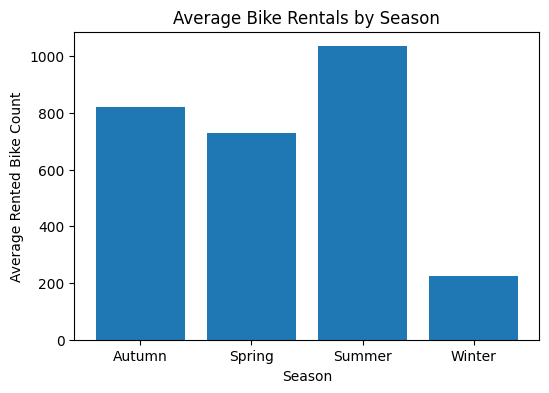

In [4]:
# Average rentals by season (full dataset)
season_avg = (
    bike_data
    .groupby('Seasons')['Rented_Bike_Count']
    .mean()
    .reset_index()
)

print(season_avg)

plt.figure(figsize=(6, 4))
plt.bar(season_avg['Seasons'], season_avg['Rented_Bike_Count'])
plt.xlabel("Season")
plt.ylabel("Average Rented Bike Count")
plt.title("Average Bike Rentals by Season")
plt.show()


Summer had the highest average hourly rental demand, at approximately 1,034 rentals per hour. The remaining modeling analysis therefore focuses on the 2,208 summer observations to study demand during the system's highest-demand season.

### Original Random-Split Validation

To preserve the original methodology, the summer observations are randomly divided 50/50 into training and test sets using `random_state=0`. A chronological validation is added later as a robustness check for future period prediction.

In [5]:
# Restrict to Summer only
bike_data_summer = bike_data[bike_data['Seasons'] == 'Summer'].copy()
print("Summer dataset shape:", bike_data_summer.shape)

# Validation split: 50% train, 50% test
train_data = bike_data_summer.sample(frac=0.5, random_state=0)
test_data  = bike_data_summer.drop(train_data.index)

print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)


Summer dataset shape: (2208, 14)
Train shape: (1104, 14)
Test shape: (1104, 14)


   Hour  Rented_Bike_Count
0     0         899.065217
1     1         698.771739
2     2         505.750000
3     3         342.673913
4     4         223.815217


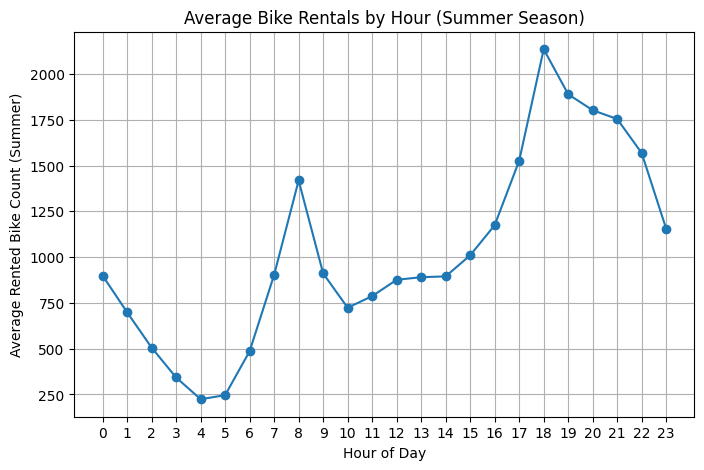

In [6]:
#average bike rentals by hour (summer)
hourly_summer = (
    bike_data_summer
    .groupby('Hour')['Rented_Bike_Count']
    .mean()
    .reset_index()
)

print(hourly_summer.head())

plt.figure(figsize=(8, 5))
plt.plot(hourly_summer['Hour'],
         hourly_summer['Rented_Bike_Count'],
         marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Average Rented Bike Count (Summer)")
plt.title("Average Bike Rentals by Hour (Summer Season)")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()


### Response Transformation

The original rental count, log-transformed count, and square-root-transformed count are compared using the training data. The square-root transformation gives the lowest absolute skewness.

Tree-based models do not need a normally distributed response, so improved symmetry is not itself a modeling requirement.

Also, to keep the results interpretable, final model performance is also evaluated on the original bike-count scale.

In [7]:
y_orig = train_data['Rented_Bike_Count']
y_log  = np.log(y_orig + 1)
y_sqrt = np.sqrt(y_orig)

print("Skewness on training set:")
print("  Original:", y_orig.skew())
print("  Log:     ", y_log.skew())
print("  Sqrt:    ", y_sqrt.skew())


Skewness on training set:
  Original: 0.727659325315091
  Log:      -1.4079389385515486
  Sqrt:     -0.051015672978781165


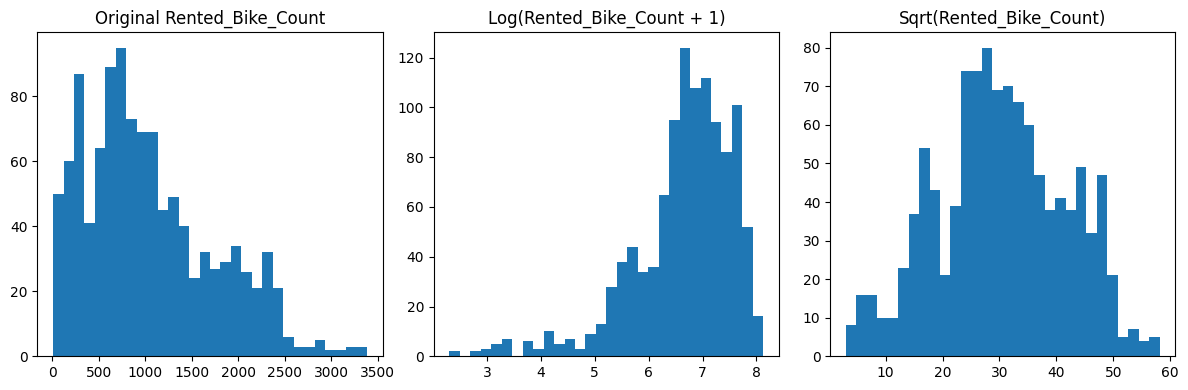

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(y_orig, bins=30)
plt.title("Original Rented_Bike_Count")

plt.subplot(1, 3, 2)
plt.hist(y_log, bins=30)
plt.title("Log(Rented_Bike_Count + 1)")

plt.subplot(1, 3, 3)
plt.hist(y_sqrt, bins=30)
plt.title("Sqrt(Rented_Bike_Count)")

plt.tight_layout()
plt.show()


In [9]:
train_data = train_data.copy()
test_data  = test_data.copy()

train_data['y'] = np.sqrt(train_data['Rented_Bike_Count'])
test_data['y']  = np.sqrt(test_data['Rented_Bike_Count'])

## 2. Bagged Tree

The Bagged Tree is implemented using `RandomForestRegressor` with all eight predictors available at every split (`max_features=8`), reproducing the behavior of bagging while retaining the original project implementation.

The number of trees is tuned over 10, 100, and 1,000 using shuffled 5-fold cross-validation with `random_state=0`.

### Model Estimation and Tuning

In [10]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# Predictor columns
predictors = [
    'Hour', 'Temperature', 'Humidity', 'Wind_speed',
    'Visibility', 'Dew_point_temperature', 'Solar_Radiation', 'Rainfall'
]

X_train = train_data[predictors]
y_train = train_data['y']

# Grid for number of trees
n_trees_grid = [10, 100, 1000]

cv_results = []

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for n in n_trees_grid:
    # Using RandomForestRegressor for bagged tree (max_features = all predictors)
    bag_model = RandomForestRegressor(
        n_estimators=n,
        max_features=len(predictors),
        random_state=0
    )

    # 5-fold cross-validation
    scores = cross_val_score(
        bag_model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_squared_error'
    )
    mean_mse = -np.mean(scores)
    cv_results.append((n, mean_mse))
    print(f"n_estimators = {n}, CV MSE = {mean_mse:.3f}")

# Pick best n based on smallest CV MSE
best_n_bag, best_mse_bag = min(cv_results, key=lambda x: x[1])
print(f"\nBest n_estimators: {best_n_bag} with CV MSE = {best_mse_bag:.3f}")

n_estimators = 10, CV MSE = 21.530
n_estimators = 100, CV MSE = 19.770
n_estimators = 1000, CV MSE = 19.703

Best n_estimators: 1000 with CV MSE = 19.703


In [11]:
# Fit final bagged model on the full training set using best_n_bag
# Using RandomForestRegressor for bagged tree (max_features = all predictors)
bagged_model = RandomForestRegressor(
    n_estimators=best_n_bag,
    max_features=len(predictors),
    random_state=0
)

bagged_model.fit(X_train, y_train)

RandomForestRegressor(max_features=8, n_estimators=1000, random_state=0)

Hour: 0.448
Temperature: 0.047
Humidity: 0.056
Wind_speed: 0.018
Visibility: 0.018
Dew_point_temperature: 0.057
Solar_Radiation: 0.146
Rainfall: 0.208


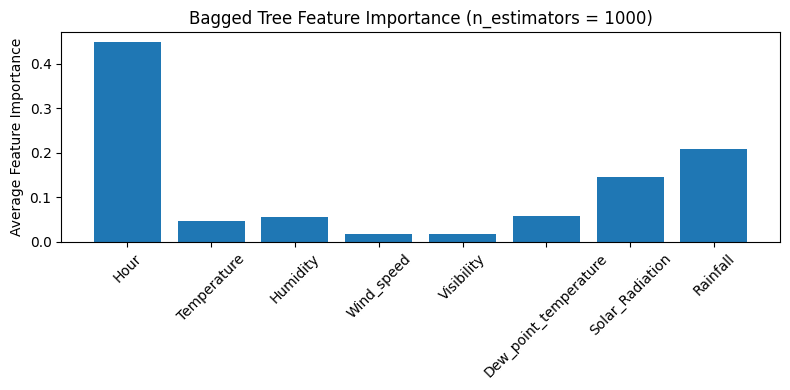

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature importances from each tree and average them
tree_importances = np.array([
    est.feature_importances_ for est in bagged_model.estimators_
])

avg_importances = tree_importances.mean(axis=0)

for name, imp in zip(predictors, avg_importances):
    print(f"{name}: {imp:.3f}")

# Plot
plt.figure(figsize=(8, 4))
plt.bar(predictors, avg_importances)
plt.xticks(rotation=45)
plt.ylabel('Average Feature Importance')
plt.title(f'Bagged Tree Feature Importance (n_estimators = {best_n_bag})')
plt.tight_layout()
plt.show()


Using the same cross-validation folds applied to the other ensemble models, the Bagged Tree had its lowest CV MSE with **1,000 trees (19.703)**. The final model uses 1,000 trees with all eight predictors available at each split.

Hour received the highest feature-importance score, indicating that time of day was the strongest predictive feature in the fitted Bagged Tree. Feature importance reflects predictive contribution within the model and should not be interpreted as evidence of causality.

## 3. Random Forest

The Random Forest differs from the Bagged Tree by considering only a subset of predictors at each split. With eight predictors, `max_features="sqrt"` introduces additional randomness across trees - giving a more diverse ensemble.

The randomness reduces correlation between trees, therefore better generalization.

The number of trees is tuned over 10, 100, and 1,000 using the same 5-fold cross-validation used for the Bagged Tree.

### Model Estimation and Tuning

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Candidate numbers of trees
n_estimators_list = [10, 100, 1000]

cv_results_rf = []

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for n in n_estimators_list:
    rf = RandomForestRegressor(
        n_estimators=n,
        max_features="sqrt",
        random_state=0,
        n_jobs=-1
    )

    # negative MSE -> we take the negative to get MSE
    neg_mse_scores = cross_val_score(
        rf,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )

    mse_scores = -neg_mse_scores
    cv_results_rf.append((n, mse_scores.mean()))
    print(f"n_estimators = {n}, CV MSE = {mse_scores.mean():.3f}")

# Pick best n
best_n_rf, best_cv_mse_rf = min(cv_results_rf, key=lambda x: x[1])
print(f"\nBest n_estimators for RF: {best_n_rf} with CV MSE = {best_cv_mse_rf:.3f}")


n_estimators = 10, CV MSE = 24.766
n_estimators = 100, CV MSE = 21.973
n_estimators = 1000, CV MSE = 21.577

Best n_estimators for RF: 1000 with CV MSE = 21.577


In [14]:
rf_final = RandomForestRegressor(
    n_estimators=best_n_rf,
    max_features="sqrt",
    random_state=0,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

RandomForestRegressor(max_features='sqrt', n_estimators=1000, n_jobs=-1,
                      random_state=0)

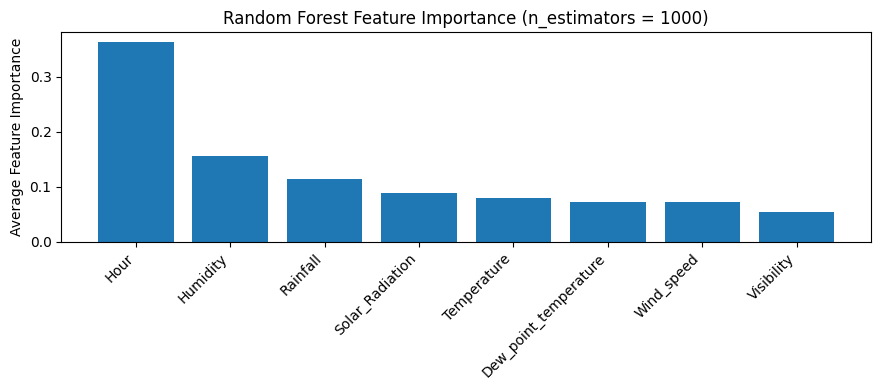

Hour: 0.363
Humidity: 0.155
Rainfall: 0.114
Solar_Radiation: 0.088
Temperature: 0.080
Dew_point_temperature: 0.073
Wind_speed: 0.072
Visibility: 0.055


In [15]:
#feature importances
import matplotlib.pyplot as plt
import numpy as np

importances_rf = rf_final.feature_importances_
indices = np.argsort(importances_rf)[::-1]

plt.figure(figsize=(9, 4))
plt.bar(range(len(predictors)), importances_rf[indices])
plt.xticks(range(len(predictors)), np.array(predictors)[indices], rotation=45, ha="right")
plt.ylabel("Average Feature Importance")
plt.title(f"Random Forest Feature Importance (n_estimators = {best_n_rf})")
plt.tight_layout()
plt.show()

for f, imp in zip(np.array(predictors)[indices], importances_rf[indices]):
    print(f"{f}: {imp:.3f}")

## 4. Gradient Boosting

The Gradient Boosting model builds shallow trees **sequentially**, with each new tree attempting to improve on the errors of the existing ensemble.

For this analysis, each tree is restricted to a decision stump (`max_depth=1`) - meaning each individual tree in the ensemble is a decision stump. Each stump corrects the errors made by previous ones.

The model is tuned across:

- `n_estimators`: 10, 100, 1,000
- `learning_rate`: 0.001, 0.01, 0.1

The same 5-fold cross-validation structure is used for comparison with the other ensemble models.

### Model Estimation and Tuning

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

n_list  = [10, 100, 1000]
lr_list = [0.001, 0.01, 0.1]

cv = KFold(n_splits=5, shuffle=True, random_state=0)

results_boost = {}

for n in n_list:
    for lr in lr_list:
        gbr = GradientBoostingRegressor(
            n_estimators=n,
            learning_rate=lr,
            max_depth=1,
            random_state=0
        )
        cv_scores = cross_val_score(
            gbr,
            X_train,
            y_train,
            cv=cv,
            scoring='neg_mean_squared_error'
        )
        mse = -cv_scores.mean()
        results_boost[(n, lr)] = mse
        print(f"n_estimators = {n:4d}, learning_rate = {lr:0.3f}, CV MSE = {mse:0.3f}")

# pick best combo
(best_n_boost, best_lr_boost), best_mse_boost = min(results_boost.items(), key=lambda x: x[1])

print("\nBest parameters for Boosting:")
print(f"n_estimators = {best_n_boost}, learning_rate = {best_lr_boost}, CV MSE = {best_mse_boost:0.3f}")


n_estimators =   10, learning_rate = 0.001, CV MSE = 128.111
n_estimators =   10, learning_rate = 0.010, CV MSE = 121.700
n_estimators =   10, learning_rate = 0.100, CV MSE = 80.429
n_estimators =  100, learning_rate = 0.001, CV MSE = 121.745
n_estimators =  100, learning_rate = 0.010, CV MSE = 81.840
n_estimators =  100, learning_rate = 0.100, CV MSE = 35.081
n_estimators = 1000, learning_rate = 0.001, CV MSE = 81.993
n_estimators = 1000, learning_rate = 0.010, CV MSE = 35.575
n_estimators = 1000, learning_rate = 0.100, CV MSE = 24.474

Best parameters for Boosting:
n_estimators = 1000, learning_rate = 0.1, CV MSE = 24.474


In [17]:
gbr_best = GradientBoostingRegressor(
    n_estimators=best_n_boost,
    learning_rate=best_lr_boost,
    max_depth=1,
    random_state=0
)

gbr_best.fit(X_train, y_train)


GradientBoostingRegressor(max_depth=1, n_estimators=1000, random_state=0)

Hour: 0.555
Temperature: 0.036
Humidity: 0.085
Wind_speed: 0.009
Visibility: 0.009
Dew_point_temperature: 0.037
Solar_Radiation: 0.045
Rainfall: 0.224


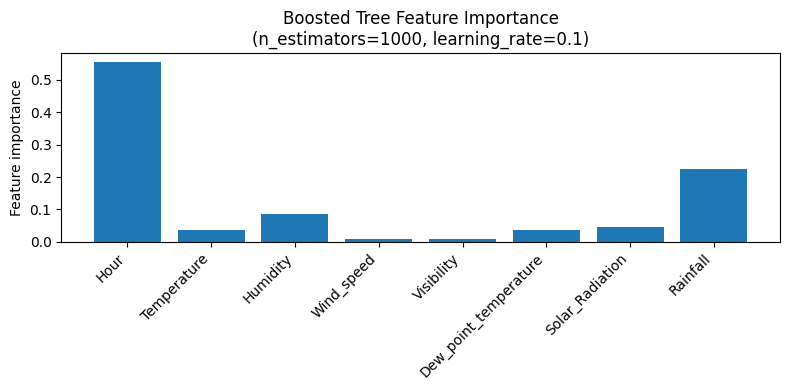

In [18]:
import matplotlib.pyplot as plt

importances = gbr_best.feature_importances_

for name, imp in zip(predictors, importances):
    print(f"{name}: {imp:.3f}")

plt.figure(figsize=(8,4))
plt.bar(predictors, importances)
plt.ylabel("Feature importance")
plt.title(
    f"Boosted Tree Feature Importance\n"
    f"(n_estimators={best_n_boost}, learning_rate={best_lr_boost})"
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


The lowest CV MSE was with **1,000 trees, a learning rate of 0.1, and `max_depth=1`**, producing a CV MSE of **24.474**.

Hour again received the highest feature-importance score, followed by Rainfall. Wind Speed and Visibility received the lowest importance scores in this fitted model. The boosted stumps a relying most heavily on changes in Hour to adjust predicted bike rental counts in the summer.

## 5. Random-Split Model Assessment

In [19]:
from sklearn.metrics import mean_squared_error

X_test = test_data[predictors]
y_test = test_data['y']   # sqrt(Rented_Bike_Count)

# 1) Bagged tree (n_estimators = 1000)
y_hat_bag = bagged_model.predict(X_test)
mse_bag = mean_squared_error(y_test, y_hat_bag)
print(f"Bagged tree test MSE: {mse_bag:.3f}")

# 2) Random forest (n_estimators = 1000, max_features='sqrt')
y_hat_rf = rf_final.predict(X_test)
mse_rf = mean_squared_error(y_test, y_hat_rf)
print(f"Random forest test MSE: {mse_rf:.3f}")

# 3) Boosted tree (n_estimators = 1000, learning_rate = 0.1, max_depth = 1)
y_hat_boost = gbr_best.predict(X_test)
mse_boost = mean_squared_error(y_test, y_hat_boost)
print(f"Boosted tree test MSE: {mse_boost:.3f}")


Bagged tree test MSE: 20.154
Random forest test MSE: 22.096
Boosted tree test MSE: 26.729


In [20]:
# model performance on the original bike-count scale

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# actual rental counts
y_test_original = test_data['Rented_Bike_Count']

# predictions from sqrt scale to bike counts
y_pred_bag_original = np.square(y_hat_bag)
y_pred_rf_original = np.square(y_hat_rf)
y_pred_boost_original = np.square(y_hat_boost)

# original scale metrics
results_original_scale = pd.DataFrame({
    'Model': ['Bagged Tree', 'Random Forest', 'Boosted Tree'],
    'MAE': [
        mean_absolute_error(y_test_original, y_pred_bag_original),
        mean_absolute_error(y_test_original, y_pred_rf_original),
        mean_absolute_error(y_test_original, y_pred_boost_original)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test_original, y_pred_bag_original)),
        np.sqrt(mean_squared_error(y_test_original, y_pred_rf_original)),
        np.sqrt(mean_squared_error(y_test_original, y_pred_boost_original))
    ],
    'R2': [
        r2_score(y_test_original, y_pred_bag_original),
        r2_score(y_test_original, y_pred_rf_original),
        r2_score(y_test_original, y_pred_boost_original)
    ]
})

print(results_original_scale.round(3))

           Model      MAE     RMSE     R2
0    Bagged Tree  191.667  291.313  0.818
1  Random Forest  209.006  305.081  0.800
2   Boosted Tree  218.275  314.177  0.788


### Random-Split Test Performance

Using the original random 50/50 summer split, all three models were evaluated on the square-root transformed response.

- **Bagged Tree:** Test MSE = 20.154
- **Random Forest:** Test MSE = 22.096
- **Gradient Boosting:** Test MSE = 26.729

The Bagged Tree produced the lowest transformed-scale test error.

This ordering is broadly consistent with the corrected cross-validation results:

- **Bagged Tree:** CV MSE = 19.703
- **Random Forest:** CV MSE = 21.577
- **Gradient Boosting:** CV MSE = 24.474

Under the original random split, the Bagged Tree had the strongest predictive performance of the three models. It achieved the lowest MSE and also performed best on the original bike-count scale, with an MAE of approximately **192 bikes**, RMSE of **291 bikes**, and R² of **0.818**.

These results portray the Bagged Tree as the strongest model under the original validation. The following temporal validation section tests whether that conclusion remains consistent when the model is evaluated on a genuinely later period.

## 6. Temporal Validation

The original random split mixes observations from throughout the same summer period between training and testing. To see performance under a more realistic setting, I added a chronological holdout.

The earliest 75% of summer observations are used for model development, while the latest 25% are held out for final evaluation. Hyperparameters are selected using `TimeSeriesSplit` within the earlier training period so that validation observations always occur after the observations used to train each fold.

### Chronological Train/Test Split

In [21]:
# chronological summer train/test split

# starting from the full summer dataset
bike_data_summer_temporal = bike_data_summer.copy()

# convert the date to datetime and sort
bike_data_summer_temporal['Date'] = pd.to_datetime(
    bike_data_summer_temporal['Date'],
    dayfirst=True
)

bike_data_summer_temporal = (
    bike_data_summer_temporal
    .sort_values(['Date', 'Hour'])
    .reset_index(drop=True)
)

# using the earliest 75% for training and latest 25% for testing
split_index = int(len(bike_data_summer_temporal) * 0.75)

temporal_train = bike_data_summer_temporal.iloc[:split_index].copy()
temporal_test = bike_data_summer_temporal.iloc[split_index:].copy()

print("Temporal train shape:", temporal_train.shape)
print("Temporal test shape:", temporal_test.shape)

print(
    "Training period:",
    temporal_train['Date'].min().date(),
    "to",
    temporal_train['Date'].max().date()
)

print(
    "Testing period:",
    temporal_test['Date'].min().date(),
    "to",
    temporal_test['Date'].max().date()
)

Temporal train shape: (1656, 14)
Temporal test shape: (552, 14)
Training period: 2018-06-01 to 2018-08-08
Testing period: 2018-08-09 to 2018-08-31


### Time-Series Cross-Validation

In [22]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# predictor and response (transformed)
X_temporal_train = temporal_train[predictors]
y_temporal_train = np.sqrt(temporal_train['Rented_Bike_Count'])

# cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# tuning number of trees
n_trees_grid = [10, 100, 1000]

temporal_cv_bag = []

for n in n_trees_grid:
    bag_model_temporal = RandomForestRegressor(
        n_estimators=n,
        max_features=len(predictors),
        random_state=0
    )

    scores = cross_val_score(
        bag_model_temporal,
        X_temporal_train,
        y_temporal_train,
        cv=tscv,
        scoring='neg_mean_squared_error'
    )

    mean_mse = -np.mean(scores)
    temporal_cv_bag.append((n, mean_mse))

    print(f"n_estimators = {n}, Temporal CV MSE = {mean_mse:.3f}")

best_n_temporal_bag, best_mse_temporal_bag = min(
    temporal_cv_bag,
    key=lambda x: x[1]
)

print(
    f"\nBest temporal Bagged Tree: "
    f"n_estimators = {best_n_temporal_bag}, "
    f"CV MSE = {best_mse_temporal_bag:.3f}"
)

n_estimators = 10, Temporal CV MSE = 35.092
n_estimators = 100, Temporal CV MSE = 34.257
n_estimators = 1000, Temporal CV MSE = 33.485

Best temporal Bagged Tree: n_estimators = 1000, CV MSE = 33.485


In [23]:
# cross validation for Random Forest

temporal_cv_rf = []

for n in n_trees_grid:
    rf_model_temporal = RandomForestRegressor(
        n_estimators=n,
        max_features="sqrt",
        random_state=0,
        n_jobs=-1
    )

    scores = cross_val_score(
        rf_model_temporal,
        X_temporal_train,
        y_temporal_train,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )

    mean_mse = -np.mean(scores)
    temporal_cv_rf.append((n, mean_mse))

    print(f"n_estimators = {n}, Temporal CV MSE = {mean_mse:.3f}")

best_n_temporal_rf, best_mse_temporal_rf = min(
    temporal_cv_rf,
    key=lambda x: x[1]
)

print(
    f"\nBest temporal Random Forest: "
    f"n_estimators = {best_n_temporal_rf}, "
    f"CV MSE = {best_mse_temporal_rf:.3f}"
)

n_estimators = 10, Temporal CV MSE = 44.474
n_estimators = 100, Temporal CV MSE = 41.177
n_estimators = 1000, Temporal CV MSE = 42.318

Best temporal Random Forest: n_estimators = 100, CV MSE = 41.177


In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# cross-validation for Gradient Boosting

n_list = [10, 100, 1000]
lr_list = [0.001, 0.01, 0.1]

temporal_cv_boost = {}

for n in n_list:
    for lr in lr_list:
        boost_model_temporal = GradientBoostingRegressor(
            n_estimators=n,
            learning_rate=lr,
            max_depth=1,
            random_state=0
        )

        scores = cross_val_score(
            boost_model_temporal,
            X_temporal_train,
            y_temporal_train,
            cv=tscv,
            scoring='neg_mean_squared_error'
        )

        mean_mse = -np.mean(scores)
        temporal_cv_boost[(n, lr)] = mean_mse

        print(
            f"n_estimators = {n:4d}, "
            f"learning_rate = {lr:0.3f}, "
            f"Temporal CV MSE = {mean_mse:.3f}"
        )

(best_n_temporal_boost, best_lr_temporal_boost), best_mse_temporal_boost = min(
    temporal_cv_boost.items(),
    key=lambda x: x[1]
)

print("\nBest temporal Gradient Boosting model:")
print(
    f"n_estimators = {best_n_temporal_boost}, "
    f"learning_rate = {best_lr_temporal_boost}, "
    f"CV MSE = {best_mse_temporal_boost:.3f}"
)

n_estimators =   10, learning_rate = 0.001, Temporal CV MSE = 134.639
n_estimators =   10, learning_rate = 0.010, Temporal CV MSE = 128.685
n_estimators =   10, learning_rate = 0.100, Temporal CV MSE = 96.631
n_estimators =  100, learning_rate = 0.001, Temporal CV MSE = 128.658
n_estimators =  100, learning_rate = 0.010, Temporal CV MSE = 97.132
n_estimators =  100, learning_rate = 0.100, Temporal CV MSE = 51.924
n_estimators = 1000, learning_rate = 0.001, Temporal CV MSE = 97.191
n_estimators = 1000, learning_rate = 0.010, Temporal CV MSE = 52.587
n_estimators = 1000, learning_rate = 0.100, Temporal CV MSE = 37.621

Best temporal Gradient Boosting model:
n_estimators = 1000, learning_rate = 0.1, CV MSE = 37.621


The time-series cross-validation selected:

- **Bagged Tree:** 1,000 trees , CV MSE = 33.485
- **Random Forest:** 100 trees , CV MSE = 41.177
- **Gradient Boosting:** 1,000 trees, learning rate 0.1, `max_depth=1` , CV MSE = 37.621

The RF configuration changed from 1,000 trees under the random-split CV to 100 trees under time-series CV, while the selected Bagged Tree and Gradient Boosting configs were unchanged.

### Future-Period Holdout Performance

In [25]:
# fitting the selected models on the full temporal training period
# I evaluate once on the future temporal test period

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_temporal_test = temporal_test[predictors]
y_temporal_test = np.sqrt(temporal_test['Rented_Bike_Count'])
y_temporal_test_original = temporal_test['Rented_Bike_Count']


#Bagged Tree:
bagged_temporal_final = RandomForestRegressor(
    n_estimators=best_n_temporal_bag,
    max_features=len(predictors),
    random_state=0
)

bagged_temporal_final.fit(X_temporal_train, y_temporal_train)
yhat_temporal_bag = bagged_temporal_final.predict(X_temporal_test)


#Random Forest:
rf_temporal_final = RandomForestRegressor(
    n_estimators=best_n_temporal_rf,
    max_features="sqrt",
    random_state=0,
    n_jobs=-1
)

rf_temporal_final.fit(X_temporal_train, y_temporal_train)
yhat_temporal_rf = rf_temporal_final.predict(X_temporal_test)


#Gradient Boosting:
boost_temporal_final = GradientBoostingRegressor(
    n_estimators=best_n_temporal_boost,
    learning_rate=best_lr_temporal_boost,
    max_depth=1,
    random_state=0
)

boost_temporal_final.fit(X_temporal_train, y_temporal_train)
yhat_temporal_boost = boost_temporal_final.predict(X_temporal_test)

# MSE for the transformed scale
print("Temporal test MSE (sqrt scale):")
print("Bagged Tree:", round(mean_squared_error(y_temporal_test, yhat_temporal_bag), 3))
print("Random Forest:", round(mean_squared_error(y_temporal_test, yhat_temporal_rf), 3))
print("Boosted Tree:", round(mean_squared_error(y_temporal_test, yhat_temporal_boost), 3))


# predictions transformed back to bike counts
yhat_temporal_bag_original = np.square(yhat_temporal_bag)
yhat_temporal_rf_original = np.square(yhat_temporal_rf)
yhat_temporal_boost_original = np.square(yhat_temporal_boost)


# metrics on original scale
temporal_results = pd.DataFrame({
    'Model': ['Bagged Tree', 'Random Forest', 'Boosted Tree'],
    'MAE': [mean_absolute_error(y_temporal_test_original, yhat_temporal_bag_original),
            mean_absolute_error(y_temporal_test_original, yhat_temporal_rf_original),
            mean_absolute_error(y_temporal_test_original, yhat_temporal_boost_original)
            ],
    'RMSE': [np.sqrt(mean_squared_error(y_temporal_test_original, yhat_temporal_bag_original)),
             np.sqrt(mean_squared_error(y_temporal_test_original, yhat_temporal_rf_original)),
             np.sqrt(mean_squared_error(y_temporal_test_original, yhat_temporal_boost_original))
             ],
    'R2': [r2_score(y_temporal_test_original, yhat_temporal_bag_original),
           r2_score(y_temporal_test_original, yhat_temporal_rf_original),
           r2_score(y_temporal_test_original, yhat_temporal_boost_original)
           ]
    })

print("Temporal test performance on original bike-count scale:")
print(temporal_results.round(3))

Temporal test MSE (sqrt scale):
Bagged Tree: 27.588
Random Forest: 30.603
Boosted Tree: 30.666
Temporal test performance on original bike-count scale:
           Model      MAE     RMSE     R2
0    Bagged Tree  202.392  297.243  0.755
1  Random Forest  227.673  312.116  0.730
2   Boosted Tree  218.435  303.407  0.745


The Bagged Tree was still the strongest model on the chronological holdout, with an MAE of approx. **202 bikes**, RMSE of **297 bikes**, and R² of **0.755**.

Performance was somewhat weaker than under the original random split, where the Bagged Tree had a MAE of approx. 192 bikes, RMSE of 291 bikes, and R² of 0.818. The decline was moderate, indicating that the model retained useful predictive performance when evaluated on a genuinely later summer period.

The temporal holdout gives us a more conservative estimate of future-period generalization.

### Random Split vs. Temporal Holdout

In [26]:
# df comparing random-split and temporal-holdout performance

random_results = results_original_scale.copy()
random_results = random_results.rename(columns={
    'MAE': 'Random Test MAE',
    'RMSE': 'Random Test RMSE',
    'R2': 'Random Test R2'
})

temporal_results_comparison = temporal_results.copy()
temporal_results_comparison = temporal_results_comparison.rename(columns={
    'MAE': 'Temporal Test MAE',
    'RMSE': 'Temporal Test RMSE',
    'R2': 'Temporal Test R2'
})

model_comparison = random_results.merge(
    temporal_results_comparison,
    on='Model'
)

print(model_comparison.round(3))

           Model  Random Test MAE  Random Test RMSE  Random Test R2  \
0    Bagged Tree          191.667           291.313           0.818   
1  Random Forest          209.006           305.081           0.800   
2   Boosted Tree          218.275           314.177           0.788   

   Temporal Test MAE  Temporal Test RMSE  Temporal Test R2  
0            202.392             297.243             0.755  
1            227.673             312.116             0.730  
2            218.435             303.407             0.745  


### Validation Comparison

The Bagged Tree had the strongest predictive performance under both the original random split and the chronological holdout. Performance was slightly weaker when predicting the period of late August, especially looking at R^2.

Nevertheless, the decline was only moderately. The Bagged Tree's RMSE increased from approximately 291 bikes (random split) to 297 bikes (temporal). The model kept useful predictive performance when evaluated on a genuinely later period.

Therefore, the temporal evaluation gives a more realistic robustness check for future-period demand prediction while still keeping the original random-split results for comparison.

### Temporal Error Analysis

In [27]:
# error analysis for the Bagged Tree (temporal)

temporal_error = temporal_test[['Date', 'Hour', 'Rented_Bike_Count']].copy()
temporal_error['Predicted_Bike_Count'] = yhat_temporal_bag_original
temporal_error['Error'] = (
    temporal_error['Predicted_Bike_Count']
    - temporal_error['Rented_Bike_Count']
)

temporal_error['Absolute_Error'] = np.abs(temporal_error['Error'])

# peak demand being the top 25% of actual rentals
peak_threshold = temporal_error['Rented_Bike_Count'].quantile(0.75)

temporal_error['Demand_Period'] = np.where(
    temporal_error['Rented_Bike_Count'] >= peak_threshold,
    'Peak Demand',
    'Non-Peak Demand'
)

# errors during peak vs non peak periods
peak_error_summary = (
    temporal_error
    .groupby('Demand_Period')
    .agg(
        Observations=('Rented_Bike_Count', 'size'),
        Average_Actual_Demand=('Rented_Bike_Count', 'mean'),
        MAE=('Absolute_Error', 'mean'),
        Mean_Error=('Error', 'mean')
    )
    .round(2)
)

print("-Peak demand threshold:", round(peak_threshold, 2))
print("-Error by demand period:")
print(peak_error_summary)


# avg absolute error by hour
hourly_error = (
    temporal_error
    .groupby('Hour')['Absolute_Error']
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

print("-Hours with largest average absolute error:")
print(hourly_error.head())

-Peak demand threshold: 1233.5
-Error by demand period:
                 Observations  Average_Actual_Demand     MAE  Mean_Error
Demand_Period                                                           
Non-Peak Demand           414                 593.43  180.08      107.12
Peak Demand               138                1749.09  269.33      -23.39
-Hours with largest average absolute error:
Hour
8     546.51
18    533.01
19    291.32
7     286.72
21    268.77
Name: Absolute_Error, dtype: float64


The Bagged Tree prediction errors were higher during periods of high demand. Using the top 25% of rentals in the temporal period as a threshold for peak demand - peak periods had an MAE of approx. **269 bikes** vs **180 bikes** in non-peak periods.

The model only slightly underpredicted peak demand observations on average, still overpredicting during non peak periods. The largest avg absolute errors happened around **8:00** and **18:00**, which also are morning/evening demand peaks.

Even though the model has useful overall demand predictions, its errors become more important during the periods when bicycle demand is highest.

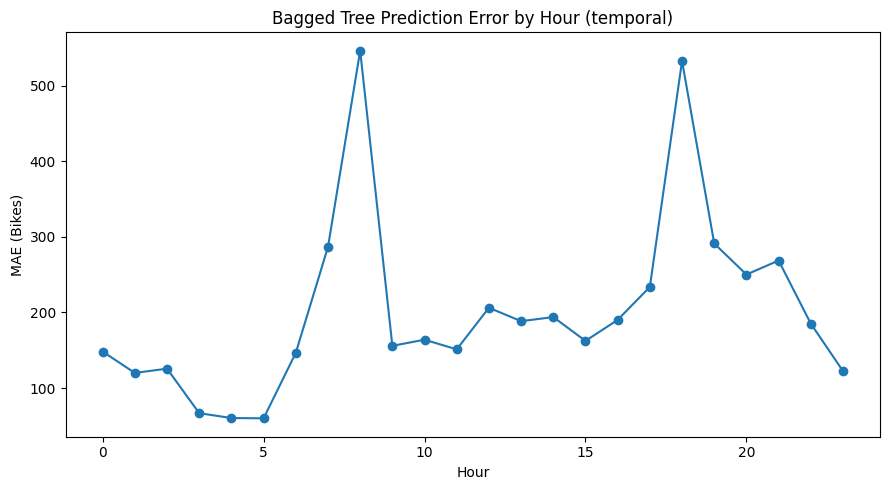

In [28]:
#avg absolute prediction error by hour plot

hourly_error_plot = (
    temporal_error
    .groupby('Hour')['Absolute_Error']
    .mean()
)

plt.figure(figsize=(9, 5))

plt.plot(
    hourly_error_plot.index,
    hourly_error_plot.values,
    marker='o'
)

plt.xlabel('Hour')
plt.ylabel('MAE (Bikes)')
plt.title('Bagged Tree Prediction Error by Hour (temporal)')
plt.tight_layout()
plt.show()

## 7. Illustrative Hourly Demand Scenario

This section depicts how the fitted models respond to changes in time of day under a fixed set of representative summer conditions.

For each hour from 0 to 23, all weather predictors are held constant at their summer mean values. The inputs are a constructed scenario.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# predictors used in all models
predictors = [
    'Hour',
    'Temperature',
    'Humidity',
    'Wind_speed',
    'Visibility',
    'Dew_point_temperature',
    'Solar_Radiation',
    'Rainfall'
]

# 1) Mean of each predictor EXCEPT Hour, over full summer dataset
mean_profile = bike_data_summer[predictors].drop(columns=['Hour']).mean()
print("Mean predictor profile (summer, excluding Hour):")
print(mean_profile)


Mean predictor profile (summer, excluding Hour):
Temperature                26.582790
Humidity                   64.981431
Wind_speed                  1.609420
Visibility               1501.745471
Dew_point_temperature      18.750136
Solar_Radiation             0.761255
Rainfall                    0.253487
dtype: float64


In [30]:
# 2) Create profile dataframe for Hours 0–23 with mean of other predictors
hours = np.arange(0, 24)

profile_df = pd.DataFrame({
    'Hour': hours,
    'Temperature': mean_profile['Temperature'],
    'Humidity': mean_profile['Humidity'],
    'Wind_speed': mean_profile['Wind_speed'],
    'Visibility': mean_profile['Visibility'],
    'Dew_point_temperature': mean_profile['Dew_point_temperature'],
    'Solar_Radiation': mean_profile['Solar_Radiation'],
    'Rainfall': mean_profile['Rainfall']
})

# 3) Predictions on sqrt-scale
yhat_bag_sqrt   = bagged_model.predict(profile_df)
yhat_rf_sqrt    = rf_final.predict(profile_df)
yhat_boost_sqrt = gbr_best.predict(profile_df)

# 4) Back-transform to original units (bike counts)
yhat_bag   = np.square(yhat_bag_sqrt)
yhat_rf    = np.square(yhat_rf_sqrt)
yhat_boost = np.square(yhat_boost_sqrt)


In [31]:
actual_hourly = (
    bike_data_summer
    .groupby('Hour')['Rented_Bike_Count']
    .mean()
    .reindex(hours)
)

print(actual_hourly.head())


Hour
0    899.065217
1    698.771739
2    505.750000
3    342.673913
4    223.815217
Name: Rented_Bike_Count, dtype: float64


### Mean-Weather Hourly Profiles

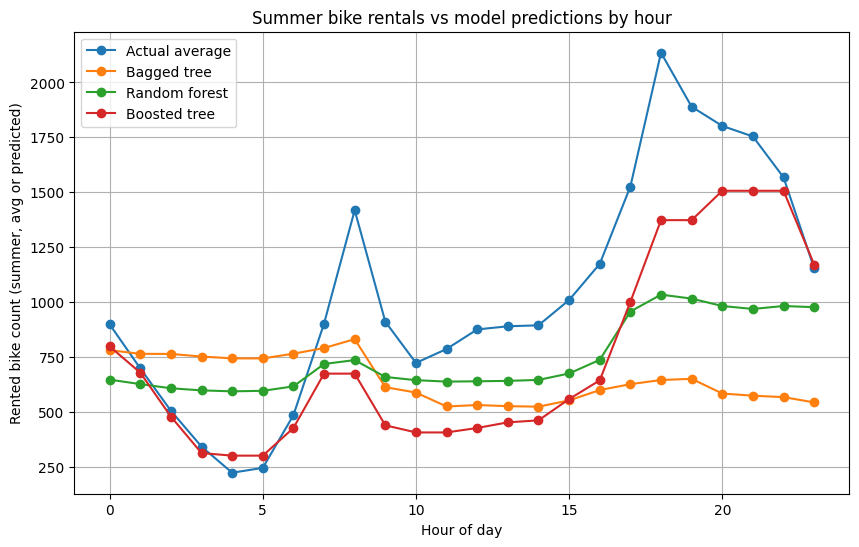

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(hours, actual_hourly.values, marker='o', label='Actual average')
plt.plot(hours, yhat_bag,   marker='o', label='Bagged tree')
plt.plot(hours, yhat_rf,    marker='o', label='Random forest')
plt.plot(hours, yhat_boost, marker='o', label='Boosted tree')

plt.xlabel('Hour of day')
plt.ylabel('Rented bike count (summer, avg or predicted)')
plt.title('Summer bike rentals vs model predictions by hour')
plt.legend()
plt.grid(True)
plt.show()


The model profiles show different predicted hourly demand patterns under the same fixed mean-weather conditions.

These scenario predictions are not directly comparable to the observed hourly averages as an accuracy test. The observed averages combine many different weather conditions, while the model profiles hold weather constant and vary only the hour. For nonlinear tree models, the prediction at average predictor values does not necessarily equal the average prediction across observed conditions.

## 8. Interpretable Decision Tree

To complement the ensemble models with a simpler interpretation, a small regression tree with four terminal nodes is fit to the full summer dataset. It gives us a compact view of many demand patterns identified in the data.

In [33]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Use full summer data
X_full = bike_data_summer[predictors]
y_full = bike_data_summer['Rented_Bike_Count']

tree_4 = DecisionTreeRegressor(
    max_leaf_nodes=4,
    random_state=0
)
tree_4.fit(X_full, y_full)


DecisionTreeRegressor(max_leaf_nodes=4, random_state=0)

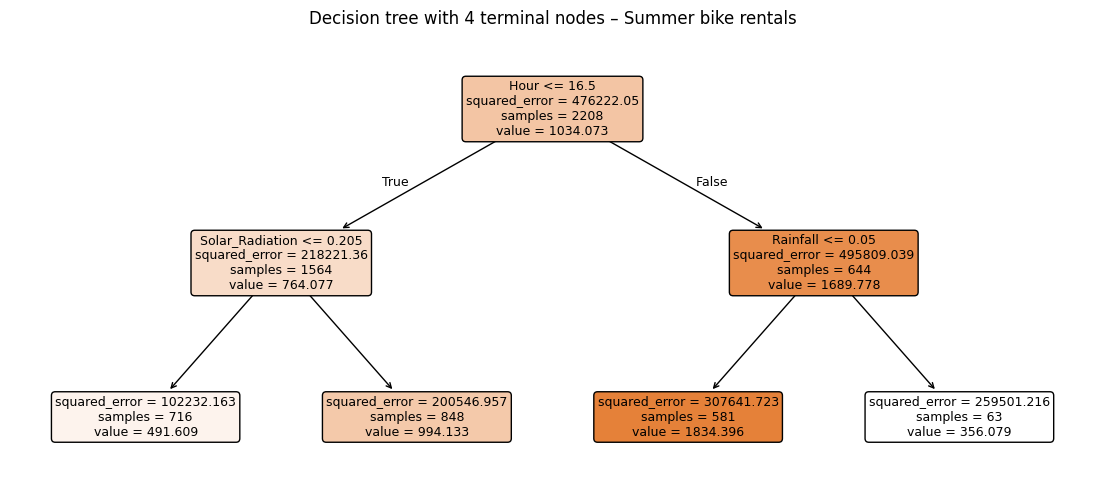

In [34]:
plt.figure(figsize=(14, 6))
plot_tree(
    tree_4,
    feature_names=predictors,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision tree with 4 terminal nodes – Summer bike rentals')
plt.show()


The first split separates observations before and after approximately 16:30, underscoring the importance of time of day in summer rental demand.

For earlier hours, the tree next separates observations using **Solar_Radiation**. For later hours, **Rainfall** becomes the next splitting variable. The highest predicted rental levels occur in later hours under little or no rainfall.

These splits give predictive patterns in the historical summer data and is not evidence that solar radiation or rainfall directly causes changes in bicycle demand.